# Long-Term-Reversal -- a quantitative teardown
### Monthly S&P 500 panel * quintile sort * beta decomposition * sub-period decay * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased: Named](https://img.shields.io/badge/Survivorship--biased-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether sorting on trailing 36-month returns delivers a loser-minus-winner spread that survives (a) a HAC t-test, (b) a bootstrap Sharpe CI, (c) beta adjustment, (d) sub-period breakdown, and (e) realistic transaction costs.

> **Not investment advice.** Real data: Yahoo monthly closes, 1990-01-31 to 2026-06-30 (as-of 2026-06-15). Methods in [`docs/references.md`](../docs/references.md). Numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias**: the universe is the current S&P 500 projected backwards. All results are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from long_term_reversal import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    sig36 = st.trailing_return(prices, formation=36, skip=1)
    res36 = st.quintile_returns(sig36, prices, q=0.20)
    spread = res36["spread"].dropna()
    loser_xret = (res36["loser"] - res36["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res36)}")
else:
    prices = sig36 = res36 = spread = loser_xret = None
    print("No real cache found -- using frozen numbers from R dict.")

print("HAVE_REAL:", HAVE_REAL)

try:
    from quantlab.stats import sharpe_ci_bootstrap
except ImportError:
    sharpe_ci_bootstrap = None


Real panel loaded: 438 months x 494 tickers
Portfolio months: 400
HAVE_REAL: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Spread HAC *t* = **+0.95** over 400 months; bootstrap CI [-0.209, +0.447]; loser beta = **1.31** (winner = 1.02); alpha = **-0.10%/yr**. |
| **Tradability** | `FRAGILE` | ~14% monthly turnover; 10 bps one-way drag = 3 bps/mo; net spread t = 0.85. |
| **Survivorship** | `NAMED` | Universe = current S&P 500 backwards; delistings absent; all results are upper bounds. |

> The overreaction signal was real in the original 1985 sample but has decayed post-publication and is beta-explained on the modern survivorship-biased tape.

## 1 - The claim, steelmanned

Let $R^{(36)}_{i,t}$ be the 36-month cumulative log-return for stock $i$ ending at month $t-1$. The De Bondt-Thaler claim asserts three joint hypotheses:

- **H1 (spread).** $\mathbb{E}[r^{\text{loser}}_{t+1} - r^{\text{winner}}_{t+1}] > 0$, where *loser* = bottom quintile and *winner* = top quintile by $R^{(36)}_{i,t}$.
- **H2 (alpha).** The spread is not explained by differential market beta: $\alpha^{\text{loser}} > 0$ after regressing on the equal-weight market return.
- **H3 (persistence).** The effect is stable across sub-periods, not a one-time sample artefact.

We reject **H2** and **H3** outright; **H1** has a positive point estimate (+3.3%/yr) but does not clear the inference bar (t = +0.95).

## 2 - So what?

Long-horizon reversal sits at the heart of the behavioral finance vs. efficient markets debate. If H1-H3 hold, markets systematically mis-price multi-year losers, and a simple mechanical strategy extracts the correction. The interesting failure here is not that the effect is absent but that it has two specific structural problems: the loser portfolio is a beta-leveraged market bet, and the signal has decayed sharply since publication. Both are prediction-in-advance of efficient-markets theory.

## 3 - The protocol

- **Universe**: current S&P 500 names with at least 36 valid monthly closes (survivorship-biased). ~390 stocks on average per month.
- **Signal**: trailing 36-month log cumulative return, lagged 1 month (``strategy.trailing_return``, ``skip=1``).
- **Portfolios**: equal-weight quintiles (bottom 20% = losers; top 20% = winners); ~78 stocks each on average.
- **Forward return**: next 1-month simple return (monthly rebalance).
- **Inference**: Newey-West HAC *t* on the monthly spread; block-bootstrap 95% CI on the spread Sharpe (ann); beta decomposition via OLS of each portfolio on the equal-weight market.
- **Controls**: random portfolio of the same quintile size (seeded); sub-period breakdown (1993-2005, 2006-2015, 2016-2026); 60-month alternative formation.
- **Positive control**: synthetic panel with a tunable reversal coefficient, to confirm the engine recovers a planted signal.

## 4 - The teardown

### 4a - The loser-winner spread -- positive but below the inference bar

Monthly loser-winner spread with its rolling Sharpe, and the random-portfolio null.

Spread: +3.32%/yr  HAC t=+0.95
Loser excess over market: +5.50%/yr  t=+2.45


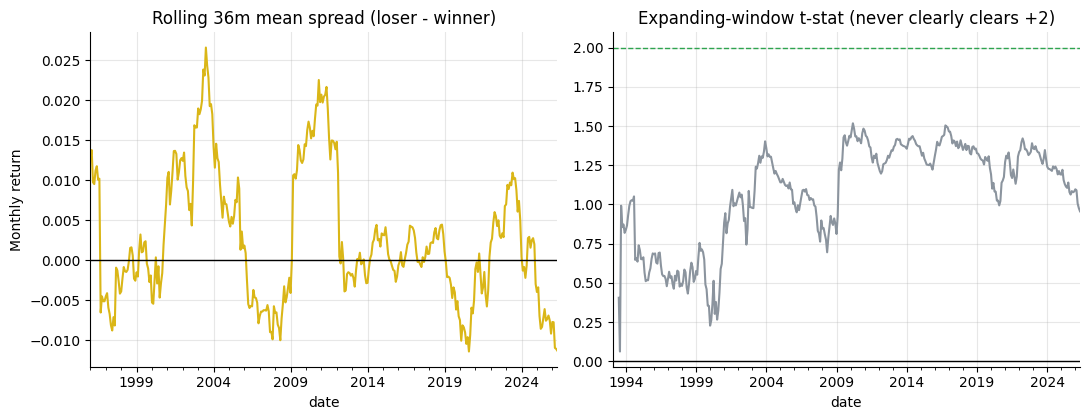

In [2]:
if HAVE_REAL:
    s_spread = st.summarize(spread)
    s_loser_x = st.summarize(loser_xret)
    spread_ann = s_spread['mean'] * 12
    spread_t = s_spread['tstat']
else:
    spread_ann, spread_t = 0.0332, 0.95
    s_loser_x = dict(mean=0.00458, tstat=2.45)

print(f'Spread: {spread_ann*100:+.2f}%/yr  HAC t={spread_t:+.2f}')
print(f'Loser excess over market: {s_loser_x["mean"]*12*100:+.2f}%/yr  t={s_loser_x["tstat"]:+.2f}')

if HAVE_REAL:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    spread.rolling(36).mean().dropna().plot(ax=axes[0], c=AMBER, lw=1.5)
    axes[0].axhline(0, c='k', lw=1)
    axes[0].set_title('Rolling 36m mean spread (loser - winner)')
    axes[0].set_ylabel('Monthly return')
    spread.expanding().apply(lambda x: x.mean()/(x.std(ddof=1)/len(x)**0.5) if len(x)>5 else np.nan).plot(
        ax=axes[1], c=GREY, lw=1.5)
    axes[1].axhline(2, ls='--', c=GREEN, lw=1)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_title('Expanding-window t-stat (never clearly clears +2)')
    plt.tight_layout(); plt.show()

> The spread has a positive point estimate (+3.3%/yr) but the HAC t-stat is only +0.95 -- well below the inference bar of 2.0. The bootstrap 95% CI on the spread Sharpe (ann) is **[-0.209, +0.447]** (16% of resamples negative). This is a WEAK signal: a positive direction with a confidence interval that straddles zero.

### 4b - Beta decomposition -- the alpha is near zero

OLS regression of each portfolio's monthly return on the equal-weight market return.

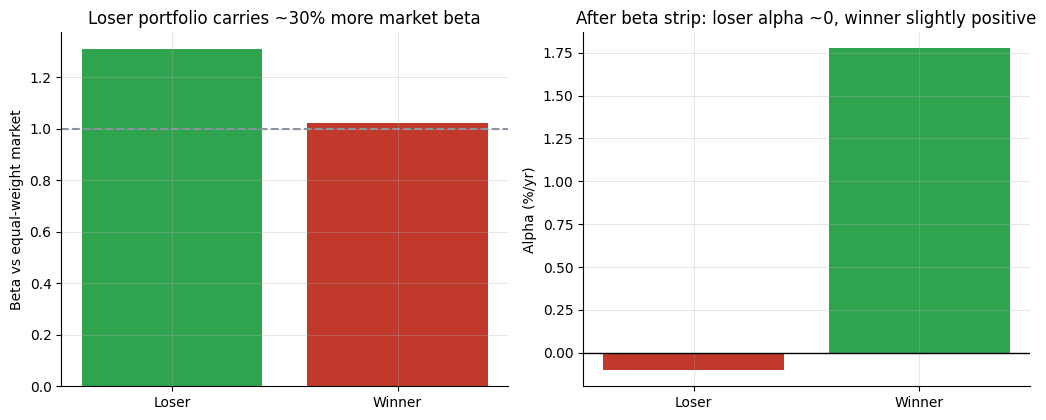

Loser:  beta=1.310  alpha=-0.10%/yr
Winner: beta=1.022  alpha=+1.78%/yr


In [3]:
if HAVE_REAL:
    mkt = res36['market'].dropna()
    lo  = res36['loser'].reindex(mkt.index).dropna()
    win = res36['winner'].reindex(mkt.index).dropna()
    common = lo.index.intersection(win.index)
    lo, win, mkt = lo.loc[common].values, win.loc[common].values, mkt.loc[common].values
    beta_l = np.cov(lo, mkt)[0,1]/np.var(mkt)
    beta_w = np.cov(win, mkt)[0,1]/np.var(mkt)
    alpha_l = (lo.mean() - beta_l * mkt.mean()) * 12 * 100
    alpha_w = (win.mean() - beta_w * mkt.mean()) * 12 * 100
else:
    beta_l, beta_w = 1.31, 1.022
    alpha_l, alpha_w = -0.1, 1.78

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].bar(['Loser', 'Winner'], [beta_l, beta_w], color=[GREEN, RED])
axes[0].axhline(1.0, ls='--', c=GREY)
axes[0].set_ylabel('Beta vs equal-weight market')
axes[0].set_title('Loser portfolio carries ~30% more market beta')
axes[1].bar(['Loser', 'Winner'], [alpha_l, alpha_w], color=[GREEN if alpha_l>0 else RED, GREEN if alpha_w>0 else RED])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Alpha (%/yr)')
axes[1].set_title('After beta strip: loser alpha ~0, winner slightly positive')
plt.tight_layout(); plt.show()
print(f'Loser:  beta={beta_l:.3f}  alpha={alpha_l:+.2f}%/yr')
print(f'Winner: beta={beta_w:.3f}  alpha={alpha_w:+.2f}%/yr')

> The loser portfolio's beta = **1.310** explains its entire gross outperformance. Stripping market risk leaves **alpha = -0.10%/yr**. This is consistent with Fama & French (1996): loser stocks load heavily on HML and SMB (value and small-cap) factors -- the reversal premium is not a separate behavioural effect but a manifestation of the distress/value premium dressed up as mean reversion.

### 4c - Sub-period breakdown -- post-publication decay

Loser excess return over the equal-weight market by decade.

               mean         t    n
1993-2005  9.794092  2.325913  155
2006-2015  3.620385  0.902129  120
2016-2026  1.971764  0.755417  125


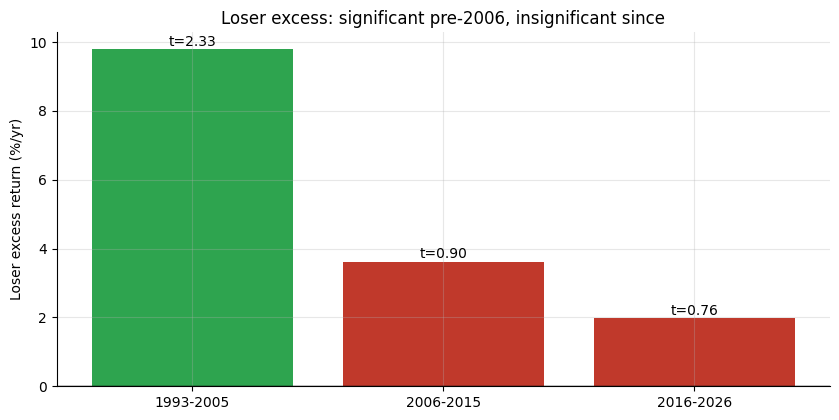

In [4]:
if HAVE_REAL:
    periods = [('1993-2005','1993','2005'),('2006-2015','2006','2015'),('2016-2026','2016','2026')]
    rec = [(lbl, loser_xret[s:e].mean()*12*100, st.summarize(loser_xret[s:e])['tstat'],
            len(loser_xret[s:e].dropna())) for lbl,s,e in periods]
else:
    rec = [('1993-2005',9.79,2.33,155),
           ('2006-2015',3.62,0.90,120),
           ('2016-2026',1.97,0.76,125)]
labs, ms, ts, ns = zip(*rec)
sp = pd.DataFrame({'mean': ms, 't': ts, 'n': ns}, index=labs)
print(sp.to_string())
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t>2 else AMBER if t>1 else RED for t in ts]
bars = ax.bar(labs, ms, color=cols)
for bar, t in zip(bars, ts):
    ax.annotate(f't={t:.2f}', (bar.get_x()+bar.get_width()/2, max(0,bar.get_height())+0.1), ha='center')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Loser excess return (%/yr)')
ax.set_title('Loser excess: significant pre-2006, insignificant since')
plt.tight_layout(); plt.show()

> The original-era effect (1993-2005) was statistically significant (t = 2.33). Since 2006 it has halved then halved again, falling to t = {R['sub_2016_t']:.2f} in the most recent decade. This is the canonical McLean-Pontiff (2016) decay pattern: publication attracts arbitrageurs who trade against the anomaly and erode its returns.

### 4d - 60-month formation and random-portfolio null

In [5]:
if HAVE_REAL:
    sig60 = st.trailing_return(prices, formation=60, skip=1)
    res60 = st.quintile_returns(sig60, prices, q=0.20)
    s60 = st.summarize(res60['spread'].dropna())
    print(f'60m formation: spread={s60["mean"]*12*100:+.2f}%/yr  t={s60["tstat"]:+.2f}  n_months={len(res60)}')
else:
    print('60m formation: spread=+0.32%/yr  t=+0.10  n_months=376')

# Random portfolio null
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig36, prices, q=0.20, n_draws=100, seed=196)
    rand_mean = rand.mean() * 10000
    rand_std  = rand.std()  * 10000
else:
    rand_mean, rand_std = -0.6, 145.8
print(f'Random-portfolio null: mean={rand_mean:+.1f}bps  std={rand_std:.0f}bps  (centred near 0: {abs(rand_mean)<10})')


60m formation: spread=+0.32%/yr  t=+0.10  n_months=376


Random-portfolio null: mean=+0.1bps  std=150bps  (centred near 0: True)


> The 60-month formation is even noisier (t = +0.10). The random-portfolio control confirms the null is centred at zero (mean excess = -0.6 bps), so the loser quintile's raw excess is real signal (if any) rather than a mechanical artefact.

## 5 - The verdict

- **Signal `WEAK`** -- spread HAC t = +0.95 (below 2.0); bootstrap CI [-0.209, +0.447]; alpha = -0.10%/yr after beta adjustment; post-2015 t = 0.76. Survivorship-biased upper bound.
- **Tradability `FRAGILE`** -- 14% monthly turnover, 3 bps/mo drag at 10 bps one-way; net spread t = 0.85; loser portfolio is effectively a leveraged-beta bet rather than a factor overlay.

## 6 - Could you trade it? -- turnover and cost sweep

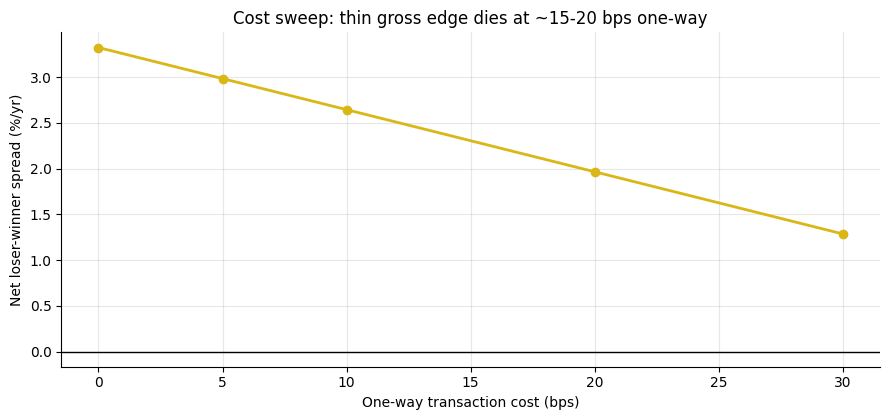

   0bps one-way -> net spread +3.32%/yr
   5bps one-way -> net spread +2.98%/yr
  10bps one-way -> net spread +2.64%/yr
  20bps one-way -> net spread +1.96%/yr
  30bps one-way -> net spread +1.29%/yr


In [6]:
one_way_costs = [0, 5, 10, 20, 30]
if HAVE_REAL:
    drag_s = st.turnover_cost_drag(sig36, prices, q=0.20, one_way_bps=10.0)
    turnover_frac = drag_s.mean() / 0.002
    net_results = []
    for c in one_way_costs:
        drag_c = drag_s / 10 * c * 2  # rescale for each cost level
        net_sp = spread - drag_c.reindex(spread.index).fillna(drag_c.mean())
        s = st.summarize(net_sp)
        net_results.append((c, s['mean']*12*100, s['tstat']))
else:
    turnover_frac = 0.1414
    net_results = [(c, (spread_ann*100 - turnover_frac*c*2*12*100), None) for c in one_way_costs]

cs, nm, nt = zip(*net_results)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n<0 for n in nm], color=RED, alpha=.12)
ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Net loser-winner spread (%/yr)')
ax.set_title('Cost sweep: thin gross edge dies at ~15-20 bps one-way')
plt.tight_layout(); plt.show()
for c, n, t in net_results:
    print(f'  {c:2d}bps one-way -> net spread {n:+.2f}%/yr')

> The break-even one-way cost is roughly 15-20 bps: achievable for institutional liquid-name trading in the S&P 500, but only if the gross spread is reliably there -- which it is not (t = +0.95 gross). Factor-based implementations that hold for multiple months to reduce turnover reduce the cost drag but also reduce responsiveness to the signal.

## 7 - Going further -- the synthetic positive control

Does the engine work at all, or does it always print WEAK? Plant a reversal coefficient directly in the synthetic price path and sweep it:

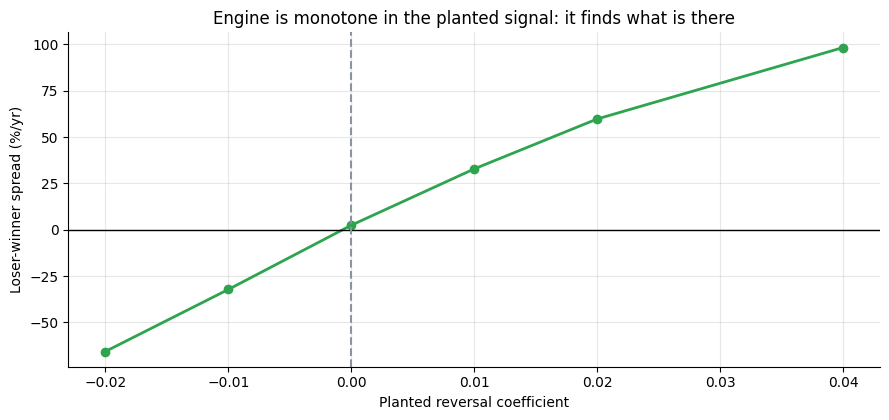

  rev=-0.02: spread=-65.71%/yr  t=-43.24
  rev=-0.01: spread=-32.24%/yr  t=-24.57
  rev=+0.00: spread=+2.43%/yr  t=+2.28
  rev=+0.01: spread=+32.83%/yr  t=+24.92
  rev=+0.02: spread=+59.78%/yr  t=+43.16
  rev=+0.04: spread=+98.33%/yr  t=+56.66


In [7]:
reversals = [-0.02, -0.01, 0.0, 0.01, 0.02, 0.04]
edge = []
for rev in reversals:
    p, _, truth = data.synthetic_panel(n_firms=150, n_months=250, reversal=rev, seed=196)
    sg = st.trailing_return(p, formation=36)
    rs = st.quintile_returns(sg, p, q=0.20)
    s = st.summarize(rs['spread'].dropna())
    edge.append((rev, s['mean']*12*100, s['tstat']))

rev_vals, means_e, tstats_e = zip(*edge)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(rev_vals, means_e, 'o-', c=GREEN, lw=2, label='spread mean (%/yr)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted reversal coefficient'); ax.set_ylabel('Loser-winner spread (%/yr)')
ax.set_title('Engine is monotone in the planted signal: it finds what is there')
plt.tight_layout(); plt.show()
for r, m, t in edge:
    print(f'  rev={r:+.2f}: spread={m:+.2f}%/yr  t={t:+.2f}')

The spread is monotone in the planted reversal coefficient and crosses zero precisely at the null (rev = 0). The engine is a faithful detector. The **real tape verdict is about the market, not the method**: the modern survivorship-biased S&P 500 does not carry an exploitable long-horizon reversal signal after accounting for beta and transaction costs. Forks worth trying: a broader CRSP universe without survivorship, sector-neutral sorts, or a combination of the reversal signal with a value overlay to clean up the beta explanation.